# Hands-on care or assistant-type help? Which need sits where

**Business question:** My business blends two services: hands-on home care (bathing, dressing, mobility) and assistant-type help (errands, paperwork, technology). Do both kinds of customers live in the same areas, or in different ones?

**Why it matters:** If both needs sit in the same ZIP codes, one blended message works everywhere. If they sit in different places, I should lead with care in some areas and with assistant help in others.

**Data:** U.S. Census Bureau American Community Survey (ACS) 5-year estimates, 2020-2024. Public and free.

**How to run:** Save a free Census API key in `census_key.txt` in the project folder (see notebook 01). Then run the cells top to bottom.

In [8]:
import os, re
import requests
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# The Census needs a free key: https://api.census.gov/data/key_signup.html
# Save it in census_key.txt in the project folder. Never paste it into this notebook.
API_KEY = os.environ.get("CENSUS_API_KEY")
KEY_FILE = "../census_key.txt"
if not API_KEY and os.path.exists(KEY_FILE):
    API_KEY = open(KEY_FILE, encoding="utf-8-sig").read().strip()
print("Using an API key:", bool(API_KEY))

Using an API key: True


## 1. Settings you can change

- **INCOME_FLOOR** is the lowest yearly household income I assume can afford ongoing help. Notebook 01 showed the top areas barely change between &#36;50,000 and &#36;100,000.
- **AREA_NAMES** are my own approximate neighborhood labels, not Census names. Edit them freely.

In [9]:
YEAR = 2024  # ACS 5-year estimates covering 2020-2024
BASE = f"https://api.census.gov/data/{YEAR}/acs/acs5"
INCOME_FLOOR = 75000

AREA_NAMES = {
    "94501": "Alameda, main island",            "94502": "Alameda, Bay Farm Island",
    "94601": "Oakland, Fruitvale",              "94602": "Oakland, Glenview / Dimond",
    "94603": "Oakland, Elmhurst",               "94605": "Oakland, East Oakland hills",
    "94606": "Oakland, San Antonio / Eastlake", "94607": "Oakland, West Oakland / Chinatown",
    "94608": "Emeryville / North Oakland",      "94609": "Oakland, Temescal",
    "94610": "Oakland, Grand Lake",             "94611": "Oakland, Montclair / Piedmont",
    "94612": "Oakland, downtown",               "94618": "Oakland, Rockridge",
    "94619": "Oakland, Laurel / Redwood Heights", "94621": "Oakland, Coliseum area",
    "94702": "Berkeley, west",                  "94703": "Berkeley, central / south",
    "94704": "Berkeley, downtown / campus",     "94705": "Berkeley, Claremont / Elmwood",
    "94707": "Berkeley, north hills",           "94708": "Berkeley hills",
    "94709": "Berkeley, north",                 "94710": "Berkeley, waterfront",
}
all_zips = list(AREA_NAMES)
print(len(all_zips), "ZIP code areas")

24 ZIP code areas


## 2. Find the Census variables by their labels

Same approach as notebook 01: pick variables by their label text, print what was picked, and stop with a clear message if something does not match.

The new one here is **self-care difficulty**: the Census asks whether a person has difficulty bathing or dressing. That is the closest public measure of who needs hands-on care.

In [10]:
def get(url, params=None):
    params = dict(params or {})
    if API_KEY:
        params["key"] = API_KEY
    r = requests.get(url, params=params, timeout=60)
    if r.status_code != 200:
        raise RuntimeError(f"Census API answered {r.status_code}: {r.text[:300]}")
    try:
        return r.json()
    except ValueError:
        title = re.search(r"<title>(.*?)</title>", r.text, re.S)
        title = title.group(1).strip() if title else r.text[:200]
        if "key" in title.lower() or not API_KEY:
            raise PermissionError(
                f"The Census did not send data (it said: {title!r}). Get a free key at "
                "https://api.census.gov/data/key_signup.html, save it in census_key.txt "
                "in the project folder, then run all cells again.")
        raise RuntimeError(f"Census API sent something that is not data: {title!r}")

meta = get(BASE + "/variables.json")["variables"]

def labels_for(table, contains=(), excludes=()):
    out = {}
    for code, info in meta.items():
        if not code.startswith(table + "_") or not code.endswith("E"):
            continue
        label = info.get("label", "")
        if all(c in label for c in contains) and not any(e in label for e in excludes):
            out[code] = label
    return dict(sorted(out.items()))

def older(d):
    return {c: l for c, l in d.items() if "65 to 74" in l or "75 years and over" in l}

age_words = ["65 and 66", "67 to 69", "70 to 74", "75 to 79", "80 to 84", "85 years and over"]
age65 = {c: l for c, l in labels_for("B01001").items() if any(a in l for a in age_words)}
selfcare = older(labels_for("B18106", contains=["With a self-care difficulty"]))
ild = older(labels_for("B18107", contains=["With an independent living difficulty"]))
hh = labels_for("B19037", contains=["Householder 65 years and over"])
hh_total = [c for c, l in hh.items() if l.endswith("Householder 65 years and over:")]

for name, d in [("self-care difficulty, 65+", selfcare), ("independent living difficulty, 65+", ild)]:
    print(f"\n{name}: {len(d)} variables")
    for c, l in d.items():
        print("  ", c, "|", l)

assert len(age65) == 12, f"Expected 12 age groups, found {len(age65)}."
assert len(selfcare) == 4, f"Expected 4 self-care variables, found {len(selfcare)}."
assert len(ild) == 4, f"Expected 4 independent-living variables, found {len(ild)}."
assert len(hh_total) == 1, "Could not find the 65+ households total in B19037."

def lower_bound(label):
    last = label.split("!!")[-1]
    if last.startswith("Less than"):
        return 0
    return int(re.search(r"\$([\d,]+)", last).group(1).replace(",", ""))

brackets = {c: lower_bound(l) for c, l in hh.items() if c not in hh_total}
hh_can_pay = [c for c, lo in brackets.items() if lo >= INCOME_FLOOR]


self-care difficulty, 65+: 4 variables
   B18106_013E | Estimate!!Total:!!Male:!!65 to 74 years:!!With a self-care difficulty
   B18106_016E | Estimate!!Total:!!Male:!!75 years and over:!!With a self-care difficulty
   B18106_029E | Estimate!!Total:!!Female:!!65 to 74 years:!!With a self-care difficulty
   B18106_032E | Estimate!!Total:!!Female:!!75 years and over:!!With a self-care difficulty

independent living difficulty, 65+: 4 variables
   B18107_010E | Estimate!!Total:!!Male:!!65 to 74 years:!!With an independent living difficulty
   B18107_013E | Estimate!!Total:!!Male:!!75 years and over:!!With an independent living difficulty
   B18107_023E | Estimate!!Total:!!Female:!!65 to 74 years:!!With an independent living difficulty
   B18107_026E | Estimate!!Total:!!Female:!!75 years and over:!!With an independent living difficulty


In [11]:
codes = list(age65) + list(selfcare) + list(ild) + hh_total + list(brackets)

def pull(codes, zips, chunk=40):
    frames = []
    for i in range(0, len(codes), chunk):
        part = codes[i:i + chunk]
        ask = {"get": "NAME," + ",".join(part)}
        try:
            rows = get(BASE, {**ask, "for": "zip code tabulation area:" + ",".join(zips)})
        except RuntimeError as err:
            print("Specific ZIP list failed, asking for all ZIP areas instead:", str(err)[:120])
            rows = get(BASE, {**ask, "for": "zip code tabulation area:*"})
        df = pd.DataFrame(rows[1:], columns=rows[0])
        df = df.rename(columns={"zip code tabulation area": "zip"}).set_index("zip")
        df = df[df.index.isin(zips)]
        frames.append(df[part].apply(pd.to_numeric, errors="coerce"))
    return pd.concat(frames, axis=1)

raw = pull(codes, all_zips)
raw = raw.where(raw >= 0)
print(raw.shape[0], "ZIP areas downloaded;", raw.isna().any(axis=1).sum(), "have missing values")

24 ZIP areas downloaded; 0 have missing values


## 3. Two pools of possible clients

The Census does not ask who wants a helper, so each pool is an estimate built from what it does measure.

- **Care pool** (hands-on care): people 65+ who have difficulty bathing or dressing, multiplied by the share of older households at or above the income floor. Roughly: people who need hands-on help and can likely pay.
- **Assistant pool** (assistant-type help): older households at or above the income floor, multiplied by the share of older residents with *no* difficulty living independently. Roughly: households that can pay and would hire help for convenience, not out of need.

The two pools use different units (people and households), so compare **ranks**, not the raw numbers. Each rank runs from 1 (largest pool) to the number of ZIP codes.

In [12]:
t = pd.DataFrame(index=raw.index)
t["area"] = t.index.map(AREA_NAMES)
residents = raw[list(age65)].sum(axis=1)
t["selfcare_65plus"] = raw[list(selfcare)].sum(axis=1)
t["share_can_pay"] = raw[hh_can_pay].sum(axis=1) / raw[hh_total[0]]
t["share_no_difficulty"] = 1 - raw[list(ild)].sum(axis=1) / residents
t["care_pool"] = t["selfcare_65plus"] * t["share_can_pay"]
t["assistant_pool"] = raw[hh_can_pay].sum(axis=1) * t["share_no_difficulty"]
t["care_rank"] = t["care_pool"].rank(ascending=False, method="min").astype(int)
t["assistant_rank"] = t["assistant_pool"].rank(ascending=False, method="min").astype(int)

# 'High' means in the top third of ZIP codes for that pool
CUT = len(t) // 3
def fit(row):
    care, assistant = row["care_rank"] <= CUT, row["assistant_rank"] <= CUT
    if care and assistant:
        return "Both"
    if care:
        return "Care-leaning"
    if assistant:
        return "Assistant-leaning"
    return "Lower priority"
t["fit"] = t.apply(fit, axis=1)
t["blend_order"] = (t["care_rank"] + t["assistant_rank"]).rank(method="first").astype(int)
t = t.sort_values("blend_order").round(2)
t

,area,selfcare_65plus,share_can_pay,share_no_difficulty,care_pool,assistant_pool,care_rank,assistant_rank,fit,blend_order
zip,,,,,,,,,,
94501,"Alameda, main island",803,0.49,0.85,394.97,2562.36,1,2,Both,1
94602,"Oakland, Glenview / Dimond",565,0.58,0.86,327.05,1799.23,2,5,Both,2
94605,"Oakland, East Oakland hills",313,0.57,0.88,177.26,2070.19,5,3,Both,3
94611,"Oakland, Montclair / Piedmont",290,0.60,0.92,174.25,3186.36,7,1,Both,4
94610,"Oakland, Grand Lake",274,0.60,0.86,164.95,1857.87,8,4,Both,5
94601,"Oakland, Fruitvale",800,0.32,0.81,253.50,932.66,3,12,Care-leaning,6
94618,"Oakland, Rockridge",210,0.68,0.93,143.61,1621.78,10,6,Assistant-leaning,7
94703,"Berkeley, central / south",440,0.52,0.83,226.66,846.72,4,13,Care-leaning,8
94619,"Oakland, Laurel / Redwood Heights",318,0.50,0.88,159.67,1253.69,9,10,Lower priority,9


## 4. Do the two needs sit in the same places?

The overlap score below runs from -1 to 1. Near 1 means areas that rank high for care also rank high for assistant help. Near 0 means no connection between the two.

In [13]:
overlap = t["care_rank"].corr(t["assistant_rank"])
if overlap >= 0.6:
    verdict = "mostly sit in the same areas"
elif overlap >= 0.3:
    verdict = "partly overlap"
else:
    verdict = "sit in different areas"
print(f"Overlap score: {overlap:.2f}  ->  care need and assistant demand {verdict}.")
print(f"('High' below means in the top {CUT} of {len(t)} ZIP codes.)\n")
for label in ["Both", "Care-leaning", "Assistant-leaning"]:
    rows = t[t["fit"] == label]
    print(f"{label} ({len(rows)}):")
    for z, row in rows.iterrows():
        print(f"   {z}  {row['area']}  (care rank {row['care_rank']}, assistant rank {row['assistant_rank']})")

Overlap score: 0.56  ->  care need and assistant demand partly overlap.
('High' below means in the top 8 of 24 ZIP codes.)

Both (5):
   94501  Alameda, main island  (care rank 1, assistant rank 2)
   94602  Oakland, Glenview / Dimond  (care rank 2, assistant rank 5)
   94605  Oakland, East Oakland hills  (care rank 5, assistant rank 3)
   94611  Oakland, Montclair / Piedmont  (care rank 7, assistant rank 1)
   94610  Oakland, Grand Lake  (care rank 8, assistant rank 4)
Care-leaning (3):
   94601  Oakland, Fruitvale  (care rank 3, assistant rank 12)
   94703  Berkeley, central / south  (care rank 4, assistant rank 13)
   94606  Oakland, San Antonio / Eastlake  (care rank 6, assistant rank 19)
Assistant-leaning (3):
   94618  Oakland, Rockridge  (care rank 10, assistant rank 6)
   94707  Berkeley, north hills  (care rank 16, assistant rank 7)
   94708  Berkeley hills  (care rank 15, assistant rank 8)


## 5. Chart: the ten best areas for the blend

Each row is one area. The blue bars show the care pool and the orange bars show the assistant pool. The two sides have their own scales, so compare bar lengths within a side, not across sides. The last column says which message to lead with there.

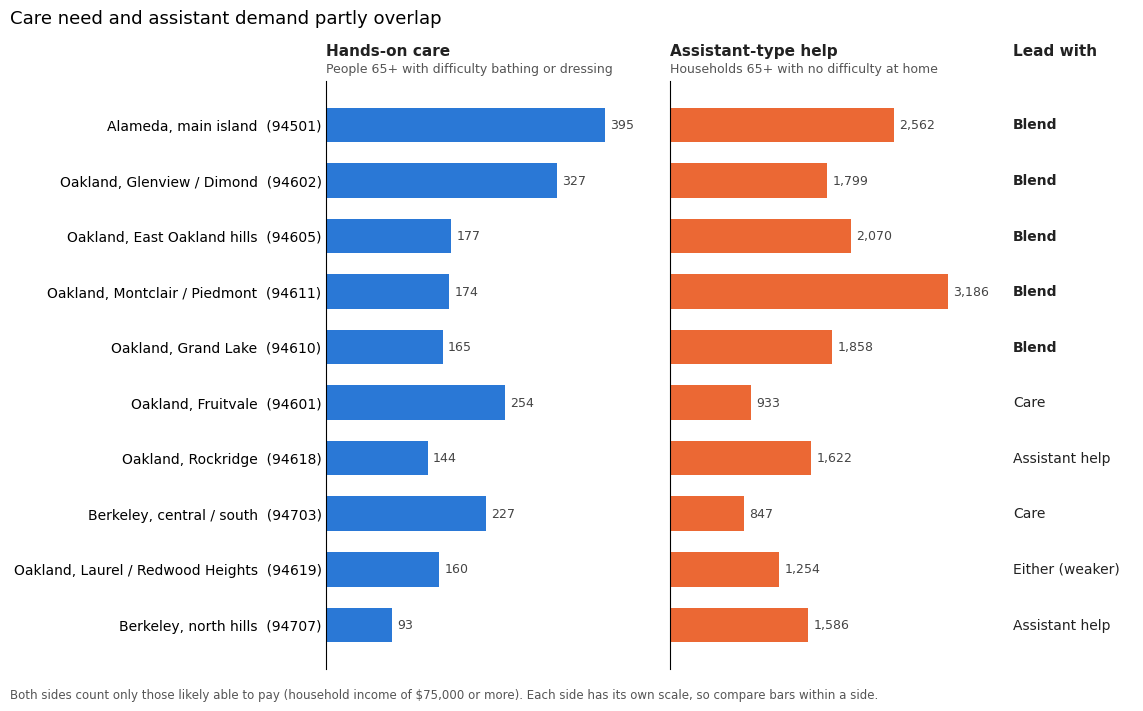

In [14]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)

show = t.head(10)
ypos = list(range(len(show)))[::-1]   # first row at the top
labels = [f"{row['area']}  ({z})" for z, row in show.iterrows()]
lead_with = {"Both": "Blend", "Care-leaning": "Care", "Assistant-leaning": "Assistant help",
             "Lower priority": "Either (weaker)"}
# Colors checked to stay distinct for colorblind readers
panels = [("care_pool", "Hands-on care", "People 65+ with difficulty bathing or dressing", "#2a78d6"),
          ("assistant_pool", "Assistant-type help", "Households 65+ with no difficulty at home", "#eb6834")]

fig, axes = plt.subplots(1, 3, figsize=(11.5, 0.45 * len(show) + 2.6), sharey=True,
                         gridspec_kw={"width_ratios": [3, 3, 1.1]})
for ax, (col, title, subtitle, color) in zip(axes, panels):
    vals = show[col].values
    ax.barh(ypos, vals, color=color, height=0.62)
    for y, v in zip(ypos, vals):
        ax.text(v + vals.max() * 0.02, y, f"{v:,.0f}", va="center", fontsize=9, color="#444444")
    ax.set_title(f"{title}\n", fontsize=11, loc="left", color="#222222", fontweight="bold")
    ax.text(0, 1.01, subtitle, transform=ax.transAxes, fontsize=9, color="#555555", va="bottom")
    ax.set_xlim(0, vals.max() * 1.18)
    ax.set_xticks([])
    ax.tick_params(axis="y", length=0)
    for side in ["top", "right", "bottom"]:
        ax.spines[side].set_visible(False)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(labels, fontsize=10)

# Third column: which message to lead with in each area
ax = axes[2]
ax.set_title("Lead with\n", fontsize=11, loc="left", color="#222222", fontweight="bold")
for y, (z, row) in zip(ypos, show.iterrows()):
    word = lead_with[row["fit"]]
    ax.text(0, y, word, va="center", fontsize=10, color="#222222",
            fontweight="bold" if word == "Blend" else "normal")
ax.set_xlim(0, 1)
ax.axis("off")

fig.suptitle(f"Care need and assistant demand {verdict}", x=0.01, ha="left", fontsize=13)
fig.text(0.01, 0.01, f"Both sides count only those likely able to pay (household income of \\${INCOME_FLOOR:,} or more). "
         "Each side has its own scale, so compare bars within a side.", fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(f"{OUT}/care_vs_assistant.png", dpi=150)
t.to_csv(f"{OUT}/care_vs_assistant.csv")
plt.show()

## 6. What I decided

- **Areas where I lead with the blend:** Alameda's main island, Glenview / Dimond, the East Oakland hills, Montclair / Piedmont and Grand Lake.
- **Areas where I lead with care:** Fruitvale, San Antonio / Eastlake, and central and south Berkeley. Fruitvale and San Antonio / Eastlake are not launch areas for me because budgets there are tight (see notebook 09).
- **Areas where I lead with assistant help:** Rockridge and the Berkeley hills.

### Limits to remember
- The Census measures difficulty and income, not who wants to hire a helper. Both pools are estimates for ranking areas, not client counts.
- The care pool applies the household "can pay" share to people, which assumes income and difficulty are unrelated. In real life, lower-income older adults report more difficulty, so the care pool is probably too high in wealthier areas and too low in poorer ones.
- ZIP-code estimates are survey-based and less reliable for small ZIP codes. Treat close ranks as ties.